### Pioreactor — Multimodal 4-Input Lorenz Chaotic Reservoir Computing [16.0-Hour Multidimensional Photothermal & Dual-Chemical Encoding Analysis]

---

### Experimental Overview
| Component | Description |
|---|---|
| **Living Reservoir** | Continuous culture of *Saccharomyces cerevisiae* in Pioreactor |
| **Input Modality 1 (Optical)** | UV-A LED (Channel C) intensity: $0.0\% \leftrightarrow 45.0\%$ ($x$-coordinate) |
| **Input Modality 2 (Thermal)** | Heating PCB schedule: $24.0°C \leftrightarrow 36.0°C$ ($y$-coordinate) |
| **Input Modality 3 (Chemical 1)** | Glucose $10\%$ on Media Pump: $0.05 \leftrightarrow 0.25\text{ mL}$ ($z$-coordinate) |
| **Input Modality 4 (Chemical 2)** | Salt (NaCl) $5\%$ on Alt-Media Pump: $0.00 \leftrightarrow 0.12\text{ mL}$ ($w$-coordinate) |
| **Step Interval** | 30.0 minutes per synchronized step ($N = 32\text{ completed steps} = 16.0\text{ hours}$) |
| **State Matrix $\mathbf{X}$** | 17 sensory channels (Measured Temp + OD $\times$ 3 + Spectrometer $\times$ 8 + nOD + Growth + $CO_2$ + RH + CO2 Temp) |

---

### Applied automations to encode the timeseries

UV  
`pio run led_automation --automation-name sine_led_automation --led-channel C --intensity-sequence "19.6, 45.0, 5.7, 6.6, 3.0, 7.0, 4.8, 4.2, 7.5, 2.7, 6.6, 6.1, 3.0, 8.2, 3.0, 6.0, 7.5, 1.9, 8.8, 3.5, 5.5, 8.7, 0.9, 9.7, 3.4, 6.3, 9.5, 0.5, 11.7, 0.0, 10.6, 6.5, 8.1, 11.9, 7.9, 14.4, 20.1, 41.1, 9.5, 8.1, 5.2, 12.9, 1.3, 15.7, 4.6, 17.8, 33.5, 19.3" --minutes-per-step 30.0
`

Temp  
` pio run temperature_automation --automation-name temperature_schedule --temperature-sequence "30.4, 32.4, 26.5, 27.6, 26.4, 27.1, 27.4, 26.2, 27.7, 26.6, 26.8, 27.8, 25.9, 27.6, 27.1, 26.4, 28.1, 25.8, 27.6, 27.5, 26.1, 28.4, 25.6, 27.7, 27.8, 26.1, 28.8, 24.9, 28.4, 26.9, 27.4, 29.2, 26.2, 29.9, 25.9, 30.5, 30.9, 32.3, 26.9, 29.2, 25.3, 29.5, 24.0, 29.8, 24.5, 30.8, 36.0, 29.7" --minutes-per-step 30.0
`

Chem  
`pio run dosing_automation --automation-name manual_dosing_control --duration 30 --volume-sequence "0.05, 0.25, 0.15, 0.16, 0.17, 0.15, 0.17, 0.16, 0.16, 0.17, 0.15, 0.17, 0.16, 0.15, 0.18, 0.15, 0.16, 0.17, 0.14, 0.18, 0.14, 0.16, 0.17, 0.14, 0.18, 0.14, 0.16, 0.16, 0.14, 0.19, 0.12, 0.18, 0.12, 0.16, 0.11, 0.16, 0.09, 0.23, 0.12, 0.17, 0.13, 0.15, 0.14, 0.14, 0.11, 0.15, 0.13, 0.14" --alt-volume-sequence "0.00, 0.12, 0.04, 0.05, 0.06, 0.05, 0.06, 0.05, 0.05, 0.06, 0.04, 0.06, 0.05, 0.04, 0.07, 0.04, 0.05, 0.06, 0.03, 0.07, 0.03, 0.05, 0.06, 0.03, 0.07, 0.03, 0.05, 0.05, 0.03, 0.08, 0.02, 0.07, 0.02, 0.05, 0.01, 0.05, 0.00, 0.10, 0.02, 0.06, 0.02, 0.04, 0.03, 0.03, 0.01, 0.04, 0.02, 0.03" --waste-ml 0.20 --pump-sequence waste_first --max-cycles 48
`


---

### Analysis & Verification Pipeline
1. **[Section 1] Ingestion & Window Truncation:** Parse all 4 input trajectories up to step 32 (16.0h) where temperature automation was active.
2. **[Section 2] Stirring Log Detection & Robust Sensor Cleaning:** Reject gas-burst spikes in $CO_2$, humidity drops, and stirring-restart growth rate transients via rolling-median Hampel filtering and time-weighted interpolation.
3. **[Section 3] 7-Subplot Multi-Panel Timeline:** Comprehensive raw sensor dynamics with UV purple shading, Glucose & Salt dosing impulse stems, and stirring stall warning markers.
4. **[Section 4] Composite Multi-Actuator Overlay:** Min-max normalized overlay comparing all 4 physical inputs against cellular responses.
5. **[Section 5] Cleaned Cycle-Mean State Matrix Aggregation:** 30-minute window averaging and feature construction on cleaned data.
6. **[Section 6] Continuous Trajectory Reconstruction (MIMO Regression):** Leave-One-Out Ridge regression across UV, Temp, Glucose, and Salt.
7. **[Section 7] Feature Importance Ranking:** Standardized Ridge weights identifying biological sensor contributions.
8. **[Section 8] Multidimensional Attractor Regime Classification:** 4-quadrant chaotic regime classification (`RidgeClassifierCV`).
9. **[Section 9] Verification Controls & Genuineness Benchmarks:** Target shuffling, circular phase lag controls, and random feature baselines to verify statistical genuineness.
10. **[Section 10] Reconstruction & Prediction Exports:** Export publication-ready plots and state tables to `data/lorenz/results/`.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
from sklearn.linear_model import Ridge, RidgeCV, RidgeClassifier, RidgeClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import LeaveOneOut, cross_val_predict
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 120

CYCLE_MIN = 30.0
TOTAL_CYCLES = 32
ALPHAS = np.logspace(-4, 6, 100)

BASE_DIR = r"data/lorenz"
if not os.path.exists(BASE_DIR):
    BASE_DIR = r"D:/omnibio/pioreactor/data/lorenz"

OUT_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(OUT_DIR, exist_ok=True)
print(f"Data directory   : {BASE_DIR}")
print(f"Results directory: {OUT_DIR}")

Data directory   : data/lorenz
Results directory: data/lorenz\results


### Section 1: Ingestion & Timeline Alignment (32 Synchronized Steps / 16.0 Hours)

In [2]:
def load_latest(pattern):
    files = sorted(glob.glob(os.path.join(BASE_DIR, pattern)))
    if not files: return None
    df = pd.read_csv(files[-1])
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
        df = df.sort_values('timestamp')
    return df

df_temp_reads = load_latest("temperature_readings-*.csv")
df_temp_events = load_latest("temperature_automation_events-*.csv")
df_led = load_latest("led_change_events-*.csv")
df_dosing = load_latest("dosing_events-*.csv")
df_co2 = load_latest("co2_readings-*.csv")
df_growth = load_latest("growth_rates-*.csv")
df_od = load_latest("od_readings-*.csv")
df_od_filt = load_latest("od_readings_filtered-*.csv")
df_spec = load_latest("as7341_spectrum_readings-*.csv")
df_logs = load_latest("logs-*.csv")

t0 = pd.to_datetime("2026-08-25 15:33:19.544Z", utc=True)
t_end = t0 + pd.Timedelta(minutes=TOTAL_CYCLES * CYCLE_MIN)

# Filter experiment window
df_temp_win = df_temp_reads[(df_temp_reads['timestamp'] >= t0) & (df_temp_reads['timestamp'] <= t_end)].copy()
df_co2_win = df_co2[(df_co2['timestamp'] >= t0) & (df_co2['timestamp'] <= t_end)].copy()
df_growth_win = df_growth[(df_growth['timestamp'] >= t0) & (df_growth['timestamp'] <= t_end)].copy()
df_od_win = df_od[(df_od['timestamp'] >= t0) & (df_od['timestamp'] <= t_end)].copy()
df_od_filt_win = df_od_filt[(df_od_filt['timestamp'] >= t0) & (df_od_filt['timestamp'] <= t_end)].copy()
df_spec_win = df_spec[(df_spec['timestamp'] >= t0) & (df_spec['timestamp'] <= t_end)].copy()
df_dosing_win = df_dosing[(df_dosing['timestamp'] >= t0) & (df_dosing['timestamp'] <= t_end)].copy()

# 48-step master sequences sliced to active 32 steps (16.0 hours)
UV_SEQ = [19.6, 45.0, 5.7, 6.6, 3.0, 7.0, 4.8, 4.2, 7.5, 2.7, 6.6, 6.1, 3.0, 8.2, 3.0, 6.0, 7.5, 1.9, 8.8, 3.5, 5.5, 8.7, 0.9, 9.7, 3.4, 6.3, 9.5, 0.5, 11.7, 0.0, 10.6, 6.5][:TOTAL_CYCLES]
TEMP_SEQ = [30.4, 32.4, 26.5, 27.6, 26.4, 27.1, 27.4, 26.2, 27.7, 26.6, 26.8, 27.8, 25.9, 27.6, 27.1, 26.4, 28.1, 25.8, 27.6, 27.5, 26.1, 28.4, 25.6, 27.7, 27.8, 26.1, 28.8, 24.9, 28.4, 26.9, 27.4, 29.2][:TOTAL_CYCLES]
GLUC_SEQ = [0.05, 0.25, 0.15, 0.16, 0.17, 0.15, 0.17, 0.16, 0.16, 0.17, 0.15, 0.17, 0.16, 0.15, 0.18, 0.15, 0.16, 0.17, 0.14, 0.18, 0.14, 0.16, 0.17, 0.14, 0.18, 0.14, 0.16, 0.16, 0.14, 0.19, 0.12, 0.18][:TOTAL_CYCLES]
SALT_SEQ = [0.00, 0.12, 0.04, 0.05, 0.06, 0.05, 0.06, 0.05, 0.05, 0.06, 0.04, 0.06, 0.05, 0.04, 0.07, 0.04, 0.05, 0.06, 0.03, 0.07, 0.03, 0.05, 0.06, 0.03, 0.07, 0.03, 0.05, 0.05, 0.03, 0.08, 0.02, 0.07][:TOTAL_CYCLES]

u_uv = np.array(UV_SEQ)
u_temp = np.array(TEMP_SEQ)
u_gluc = np.array(GLUC_SEQ)
u_salt = np.array(SALT_SEQ)

print("=== EXPERIMENTAL SUMMARY ===")
print(f"Experiment Start (Step 0) : {t0}")
print(f"Experiment End   (Step 31): {t_end}")
print(f"Valid Duration            : {TOTAL_CYCLES * CYCLE_MIN / 60.0:.1f} Hours ({TOTAL_CYCLES} synchronized steps x 30 min)")
print(f"Sensory Measurements      : {len(df_spec_win)} Spec, {len(df_od_win)} OD, {len(df_co2_win)} CO2, {len(df_temp_win)} Temp readings")

=== EXPERIMENTAL SUMMARY ===
Experiment Start (Step 0) : 2026-08-25 15:33:19.544000+00:00
Experiment End   (Step 31): 2026-08-26 07:33:19.544000+00:00
Valid Duration            : 16.0 Hours (32 synchronized steps x 30 min)
Sensory Measurements      : 92160 Spec, 34560 OD, 1889 CO2, 280 Temp readings


### Section 2: Stirring Failure Log Detection & Outlier Rejection (CO2, Humidity, Growth Rate)

In [3]:
# 1. Flag stirring failure timestamps from logs
stir_fail_mask = df_logs['message'].str.contains("Stirring RPM is 0", case=False, na=False)
stir_fail_times = df_logs[stir_fail_mask & (df_logs['timestamp'] >= t0) & (df_logs['timestamp'] <= t_end)]['timestamp'].values
print(f"Detected {len(stir_fail_times)} stirring RPM=0 events during the active 16.0h window.")

# 2. Robust CO2 Cleaning (Outlier rejection + Stirring mask + Time interpolation)
df_co2_clean = df_co2_win.copy().set_index('timestamp')
rolling_med_co2 = df_co2_clean['co2_reading_ppm'].rolling(25, center=True).median()
diff_co2 = np.abs(df_co2_clean['co2_reading_ppm'] - rolling_med_co2)
co2_outliers = (diff_co2 > 50) | (df_co2_clean['co2_reading_ppm'] > 1000)
for st in stir_fail_times:
    t_s = pd.to_datetime(st, utc=True)
    co2_outliers |= (df_co2_clean.index >= t_s - pd.Timedelta(seconds=30)) & (df_co2_clean.index <= t_s + pd.Timedelta(minutes=5))
df_co2_clean.loc[co2_outliers, 'co2_reading_ppm'] = np.nan
df_co2_clean['co2_reading_ppm'] = df_co2_clean['co2_reading_ppm'].interpolate(method='time', limit_direction='both')

# 3. Robust Humidity Cleaning
rolling_med_hum = df_co2_clean['relative_humidity'].rolling(25, center=True).median()
diff_hum = np.abs(df_co2_clean['relative_humidity'] - rolling_med_hum)
hum_outliers = (diff_hum > 3.0) | (df_co2_clean['relative_humidity'] < 70.0)
df_co2_clean.loc[hum_outliers, 'relative_humidity'] = np.nan
df_co2_clean['relative_humidity'] = df_co2_clean['relative_humidity'].interpolate(method='time', limit_direction='both')
df_co2_clean = df_co2_clean.reset_index()

# 4. Robust Growth Rate Cleaning (Reject transient stirring restart spikes)
df_growth_clean = df_growth_win.copy().set_index('timestamp')
rolling_med_gr = df_growth_clean['rate'].rolling(100, center=True).median()
diff_gr = np.abs(df_growth_clean['rate'] - rolling_med_gr)
gr_outliers = (diff_gr > 0.005)
for st in stir_fail_times:
    t_s = pd.to_datetime(st, utc=True)
    gr_outliers |= (df_growth_clean.index >= t_s - pd.Timedelta(minutes=1)) & (df_growth_clean.index <= t_s + pd.Timedelta(minutes=4))
df_growth_clean.loc[gr_outliers, 'rate'] = np.nan
df_growth_clean['rate'] = df_growth_clean['rate'].interpolate(method='time', limit_direction='both')
df_growth_clean = df_growth_clean.reset_index()

print(f"Cleaning Summary:")
print(f"  • Cleaned {co2_outliers.sum()} CO2 outlier samples")
print(f"  • Cleaned {hum_outliers.sum()} Humidity outlier samples")
print(f"  • Cleaned {gr_outliers.sum()} Growth Rate outlier samples")

Detected 10 stirring RPM=0 events during the active 16.0h window.
Cleaning Summary:
  • Cleaned 377 CO2 outlier samples
  • Cleaned 21 Humidity outlier samples
  • Cleaned 151 Growth Rate outlier samples


### Section 3: 7-Subplot Multi-Panel Sensor Timeline

Saved enhanced 7-panel raw sensor timeline to: data/lorenz\results\raw_sensors_timeline.png


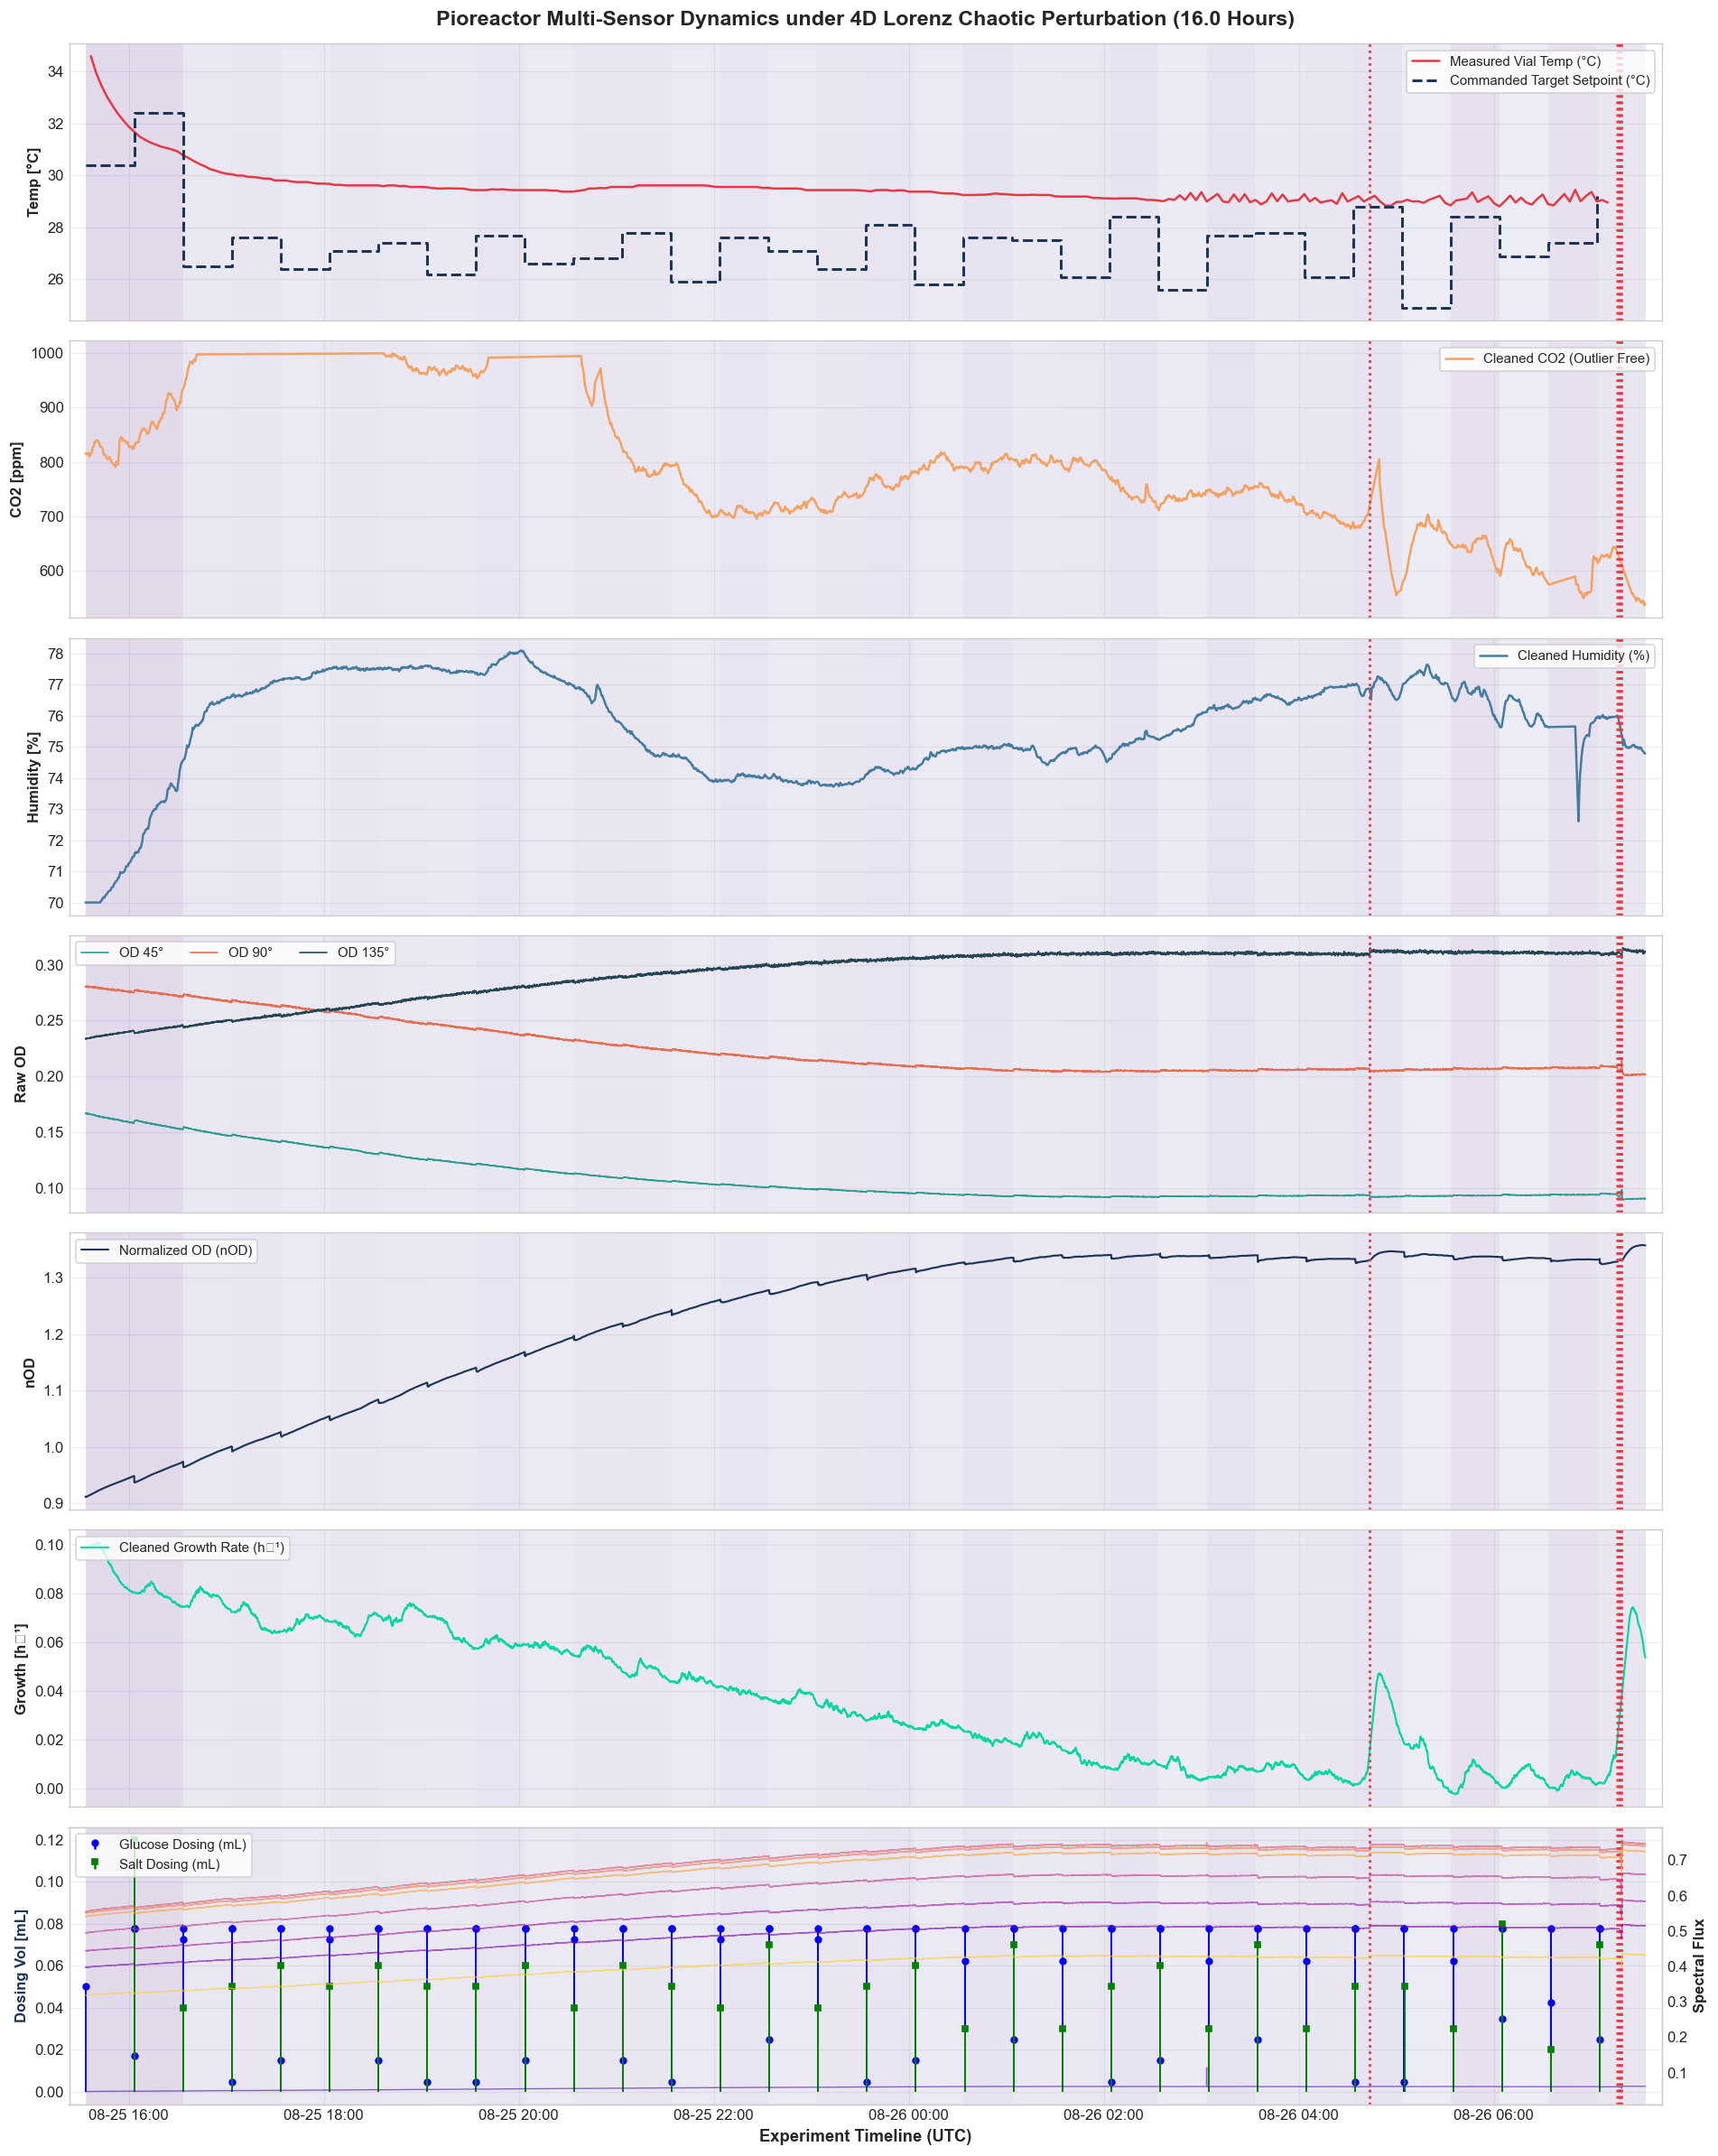

In [4]:
df_od_piv = df_od_win.pivot_table(index=df_od_win['timestamp'].dt.floor('s'), columns='angle', values='od_reading', aggfunc='mean')
df_od_piv.columns = [f'OD_{col}' for col in df_od_piv.columns]

df_spec_piv = df_spec_win.pivot_table(index=df_spec_win['timestamp'].dt.floor('s'), columns='band', values='reading', aggfunc='mean')
df_spec_piv.columns = [f'nm_{col}' for col in df_spec_piv.columns]

fig, axes = plt.subplots(7, 1, figsize=(16, 20), sharex=True)

step_times = [t0 + pd.Timedelta(minutes=i*CYCLE_MIN) for i in range(TOTAL_CYCLES)]
step_times_ext = step_times + [t_end]

def add_uv_shading(ax):
    cmap = cm.Purples
    for i in range(TOTAL_CYCLES):
        t_a = step_times[i]
        t_b = step_times[i+1] if i < TOTAL_CYCLES - 1 else t_end
        val = u_uv[i]
        norm_val = val / 45.0
        color = cmap(0.6 + 0.9 * norm_val)
        ax.axvspan(t_a, t_b, color=color, alpha=0.15, lw=0)

# 1. Temperature (Measured vs Commanded Target)
axes[0].plot(df_temp_win['timestamp'], df_temp_win['temperature_c'], color='#e63946', lw=1.5, label='Measured Vial Temp (°C)')
axes[0].step(step_times, u_temp, where='post', color='#1d3557', lw=1.8, ls='--', label='Commanded Target Setpoint (°C)')
axes[0].set_ylabel('Temp [°C]', fontweight='bold')
axes[0].set_title('Pioreactor Multi-Sensor Dynamics under 4D Lorenz Chaotic Perturbation (16.0 Hours)', fontsize=14, fontweight='bold', pad=12)
axes[0].legend(loc='upper right', frameon=True, fontsize=9)

# 2. Cleaned CO2 (Outlier Free)
axes[1].plot(df_co2_clean['timestamp'], df_co2_clean['co2_reading_ppm'], color='#f4a261', lw=1.5, label='Cleaned CO2 (Outlier Free)')
axes[1].set_ylabel('CO2 [ppm]', fontweight='bold')
axes[1].legend(loc='upper right', frameon=True, fontsize=9)

# 3. Cleaned Humidity
axes[2].plot(df_co2_clean['timestamp'], df_co2_clean['relative_humidity'], color='#457b9d', lw=1.5, label='Cleaned Humidity (%)')
axes[2].set_ylabel('Humidity [%]', fontweight='bold')
axes[2].legend(loc='upper right', frameon=True, fontsize=9)

# 4. Optical Density (3 Angles)
axes[3].plot(df_od_piv.index, df_od_piv['OD_45'], color='#2a9d8f', lw=1.0, label='OD 45°')
axes[3].plot(df_od_piv.index, df_od_piv['OD_90'], color='#e76f51', lw=1.0, label='OD 90°')
axes[3].plot(df_od_piv.index, df_od_piv['OD_135'], color='#264653', lw=1.0, label='OD 135°')
axes[3].set_ylabel('Raw OD', fontweight='bold')
axes[3].legend(loc='upper left', ncol=3, frameon=True, fontsize=9)

# 5. Normalized OD
axes[4].plot(df_od_filt_win['timestamp'], df_od_filt_win['normalized_od_reading'], color='#1d3557', lw=1.3, label='Normalized OD (nOD)')
axes[4].set_ylabel('nOD', fontweight='bold')
axes[4].legend(loc='upper left', frameon=True, fontsize=9)

# 6. Cleaned Growth Rate
axes[5].plot(df_growth_clean['timestamp'], df_growth_clean['rate'], color='#06d6a0', lw=1.3, label='Cleaned Growth Rate (h⁻¹)')
axes[5].set_ylabel('Growth [h⁻¹]', fontweight='bold')
axes[5].legend(loc='upper left', frameon=True, fontsize=9)

# 7. Dosing Impulses (Glucose & Salt) + Spectrometer 8 Bands on secondary axis
dosing_media = df_dosing_win[df_dosing_win['event'] == 'add_media']
dosing_alt = df_dosing_win[df_dosing_win['event'] == 'add_alt_media']

markerline, stemlines, baseline = axes[6].stem(dosing_media['timestamp'], dosing_media['volume_change_ml'], linefmt='b-', markerfmt='bo', basefmt=' ', label='Glucose Dosing (mL)')
plt.setp(stemlines, 'linewidth', 1.2)
plt.setp(markerline, 'markersize', 4)

markerline2, stemlines2, baseline2 = axes[6].stem(dosing_alt['timestamp'], dosing_alt['volume_change_ml'], linefmt='g-', markerfmt='gs', basefmt=' ', label='Salt Dosing (mL)')
plt.setp(stemlines2, 'linewidth', 1.2)
plt.setp(markerline2, 'markersize', 4)
axes[6].set_ylabel('Dosing Vol [mL]', fontweight='bold', color='#1d3557')
axes[6].legend(loc='upper left', frameon=True, fontsize=9)

ax6_twin = axes[6].twinx()
spec_colors = cm.plasma(np.linspace(0.1, 0.9, 8))
for idx, band in enumerate([415, 445, 480, 515, 555, 590, 630, 680]):
    col = f'nm_{band}'
    if col in df_spec_piv.columns:
        ax6_twin.plot(df_spec_piv.index, df_spec_piv[col], color=spec_colors[idx], lw=0.8, alpha=0.6, label=f'{band}nm')
ax6_twin.set_ylabel('Spectral Flux', fontweight='bold')
ax6_twin.grid(False)

for ax in axes:
    add_uv_shading(ax)
    for st in stir_fail_times:
        ax.axvline(pd.to_datetime(st, utc=True), color='#e63946', ls=':', alpha=0.8, lw=1.6)
    ax.set_xlim(t0 - pd.Timedelta(minutes=10), t_end + pd.Timedelta(minutes=10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    ax.grid(True, alpha=0.3)

axes[6].set_xlabel('Experiment Timeline (UTC)', fontweight='bold', fontsize=11)
plt.tight_layout()
raw_plot_path = os.path.join(OUT_DIR, "raw_sensors_timeline.png")
plt.savefig(raw_plot_path, dpi=150)
print(f"Saved enhanced 7-panel raw sensor timeline to: {raw_plot_path}")
plt.show()

### Section 4: Cleaned 30-Minute Cycle-Mean State Matrix Aggregation

In [5]:
def get_cycle_mean(df, val_col, filter_col=None, filter_val=None):
    if df is None: return pd.Series(0.0, index=range(TOTAL_CYCLES))
    tmp = df.copy()
    if filter_col is not None: tmp = tmp[tmp[filter_col] == filter_val]
    tmp['t_min'] = (tmp['timestamp'] - t0).dt.total_seconds() / 60.0
    tmp = tmp[(tmp['t_min'] >= -5) & (tmp['t_min'] < TOTAL_CYCLES * CYCLE_MIN + 5)]
    tmp['cycle'] = np.floor(np.clip(tmp['t_min'], 0, TOTAL_CYCLES * CYCLE_MIN - 1e-3) / CYCLE_MIN).astype(int)
    return tmp.groupby('cycle')[val_col].mean().reindex(range(TOTAL_CYCLES)).interpolate(limit_direction='both')

features = {}
features['measured_temp_c'] = get_cycle_mean(df_temp_win, 'temperature_c')
features['OD_45'] = get_cycle_mean(df_od_win, 'od_reading', 'angle', 45)
features['OD_90'] = get_cycle_mean(df_od_win, 'od_reading', 'angle', 90)
features['OD_135'] = get_cycle_mean(df_od_win, 'od_reading', 'angle', 135)

for band in [415, 445, 480, 515, 555, 590, 630, 680]:
    features[f'nm_{band}'] = get_cycle_mean(df_spec_win, 'reading', 'band', band)

features['growth_rate'] = get_cycle_mean(df_growth_clean, 'rate')
features['norm_od'] = get_cycle_mean(df_od_filt_win, 'normalized_od_reading')
features['co2_ppm'] = get_cycle_mean(df_co2_clean, 'co2_reading_ppm')
features['co2_temp_c'] = get_cycle_mean(df_co2_clean, 'temperature_c')
features['humidity'] = get_cycle_mean(df_co2_clean, 'relative_humidity')

df_cycles = pd.DataFrame(features).bfill().ffill()
sensor_names = list(df_cycles.columns)
X_raw = df_cycles.values

# Export state matrix
df_state_exp = df_cycles.copy()
df_state_exp['u_uv_intensity_pct'] = u_uv
df_state_exp['u_target_temp_c'] = u_temp
df_state_exp['u_glucose_ml'] = u_gluc
df_state_exp['u_salt_ml'] = u_salt
state_csv_path = os.path.join(OUT_DIR, "lorenz_state_matrix.csv")
df_state_exp.to_csv(state_csv_path, index=False)
print(f"Saved cleaned state matrix ({len(df_state_exp)} cycles x {df_state_exp.shape[1]} columns) to: {state_csv_path}")

Saved cleaned state matrix (32 cycles x 21 columns) to: data/lorenz\results\lorenz_state_matrix.csv


### Section 5: Continuous Trajectory Reconstruction (MIMO Ridge Regression)

In [6]:
def delay_embed(X: np.ndarray, y: np.ndarray, delay: int):
    if delay == 0: return X.copy(), y.copy()
    rows = []
    for t in range(delay, len(X)):
        rows.append(np.concatenate([X[t - lag] for lag in range(delay + 1)]))
    return np.asarray(rows), y[delay:]

def ridge_loo_reg(X: np.ndarray, y: np.ndarray):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    rcv = RidgeCV(alphas=ALPHAS, cv=None)
    rcv.fit(Xs, y)
    model = Ridge(alpha=rcv.alpha_)
    yp = cross_val_predict(model, Xs, y, cv=LeaveOneOut())
    nmse = mean_squared_error(y, yp) / (np.var(y) + 1e-8)
    mae = mean_absolute_error(y, yp)
    r2 = r2_score(y, yp)
    return yp, nmse, mae, r2, rcv.alpha_

targets = [
    ("UV Intensity (%)", u_uv),
    ("Temperature (°C)", u_temp),
    ("Glucose (mL)", u_gluc),
    ("Salt (mL)", u_salt)
]

print("=" * 78)
print(f"{'Target Input':<22}  {'Delay':<8}  {'Memory (min)':<14}  {'R2':>8}  {'NMSE':>8}  {'MAE':>10}")
print("=" * 78)

best_reconstructions = {}
MAX_DELAY = 10  # Sweep delay embedding from d=0 (0 min) up to d=10 (300 min = 5.0 hours)

for name, y_t in targets:
    best_r2 = -999
    best_pack = None
    print(f"\n--- {name} (Delay Sweep d=0..{MAX_DELAY}) ---")
    for d in range(MAX_DELAY + 1):
        Xd, yd = delay_embed(X_raw, y_t, d)
        yp, nmse, mae, r2, alpha = ridge_loo_reg(Xd, yd)
        if r2 > best_r2:
            best_r2 = r2
            best_pack = (d, yp, yd, nmse, mae, r2)
        print(f"{name:<22}  d={d:<6}  {d*30:<14}  {r2:>8.4f}  {nmse:>8.4f}  {mae:>10.4f}")
    best_reconstructions[name] = best_pack
print("=" * 78)

Target Input            Delay     Memory (min)          R2      NMSE         MAE

--- UV Intensity (%) (Delay Sweep d=0..10) ---
UV Intensity (%)        d=0       0                 0.0929    0.9071      4.4398
UV Intensity (%)        d=1       30                0.0715    0.9285      5.7461


UV Intensity (%)        d=2       60               -0.0702    1.0702      2.5523
UV Intensity (%)        d=3       90               -0.0728    1.0728      2.6418
UV Intensity (%)        d=4       120              -0.0755    1.0755      2.7067
UV Intensity (%)        d=5       150              -0.0785    1.0785      2.6994
UV Intensity (%)        d=6       180              -0.0817    1.0817      2.7595
UV Intensity (%)        d=7       210              -0.0852    1.0852      2.8346


UV Intensity (%)        d=8       240              -0.0891    1.0891      2.8823
UV Intensity (%)        d=9       270              -0.0931    1.0931      2.9443
UV Intensity (%)        d=10      300              -0.0978    1.0978      2.9169

--- Temperature (°C) (Delay Sweep d=0..10) ---
Temperature (°C)        d=0       0                 0.1282    0.8718      1.0196
Temperature (°C)        d=1       30               -0.0679    1.0679      0.9906


Temperature (°C)        d=2       60               -0.0702    1.0702      0.8483
Temperature (°C)        d=3       90                0.2350    0.7650      0.7697
Temperature (°C)        d=4       120              -0.0568    1.0568      0.7836
Temperature (°C)        d=5       150              -0.0785    1.0785      0.8752


Temperature (°C)        d=6       180              -0.0817    1.0817      0.9084
Temperature (°C)        d=7       210              -0.0851    1.0851      0.9360
Temperature (°C)        d=8       240              -0.0890    1.0890      0.9327
Temperature (°C)        d=9       270              -0.0931    1.0931      0.9521
Temperature (°C)        d=10      300              -0.0977    1.0977      0.9689

--- Glucose (mL) (Delay Sweep d=0..10) ---


Glucose (mL)            d=0       0                -0.0657    1.0657      0.0184
Glucose (mL)            d=1       30               -0.0669    1.0669      0.0156
Glucose (mL)            d=2       60               -0.0702    1.0702      0.0126
Glucose (mL)            d=3       90               -0.0728    1.0727      0.0126
Glucose (mL)            d=4       120              -0.0755    1.0755      0.0131


Glucose (mL)            d=5       150              -0.0785    1.0785      0.0133
Glucose (mL)            d=6       180              -0.0817    1.0816      0.0133
Glucose (mL)            d=7       210              -0.0852    1.0852      0.0136
Glucose (mL)            d=8       240              -0.0890    1.0890      0.0141
Glucose (mL)            d=9       270              -0.0932    1.0932      0.0147


Glucose (mL)            d=10      300              -0.0978    1.0978      0.0150

--- Salt (mL) (Delay Sweep d=0..10) ---
Salt (mL)               d=0       0                -0.0657    1.0656      0.0150
Salt (mL)               d=1       30               -0.0656    1.0655      0.0142
Salt (mL)               d=2       60               -0.0702    1.0702      0.0117


Salt (mL)               d=3       90               -0.0727    1.0727      0.0119
Salt (mL)               d=4       120              -0.0755    1.0754      0.0123
Salt (mL)               d=5       150              -0.0785    1.0784      0.0123
Salt (mL)               d=6       180              -0.0817    1.0816      0.0128


Salt (mL)               d=7       210              -0.0852    1.0852      0.0130
Salt (mL)               d=8       240              -0.0890    1.0890      0.0136
Salt (mL)               d=9       270              -0.0932    1.0932      0.0142
Salt (mL)               d=10      300              -0.0978    1.0978      0.0145


### Section 6: Feature Importance Ranking (Standardized Ridge Weights)

Saved feature importance ranking to: data/lorenz\results\feature_importance.png


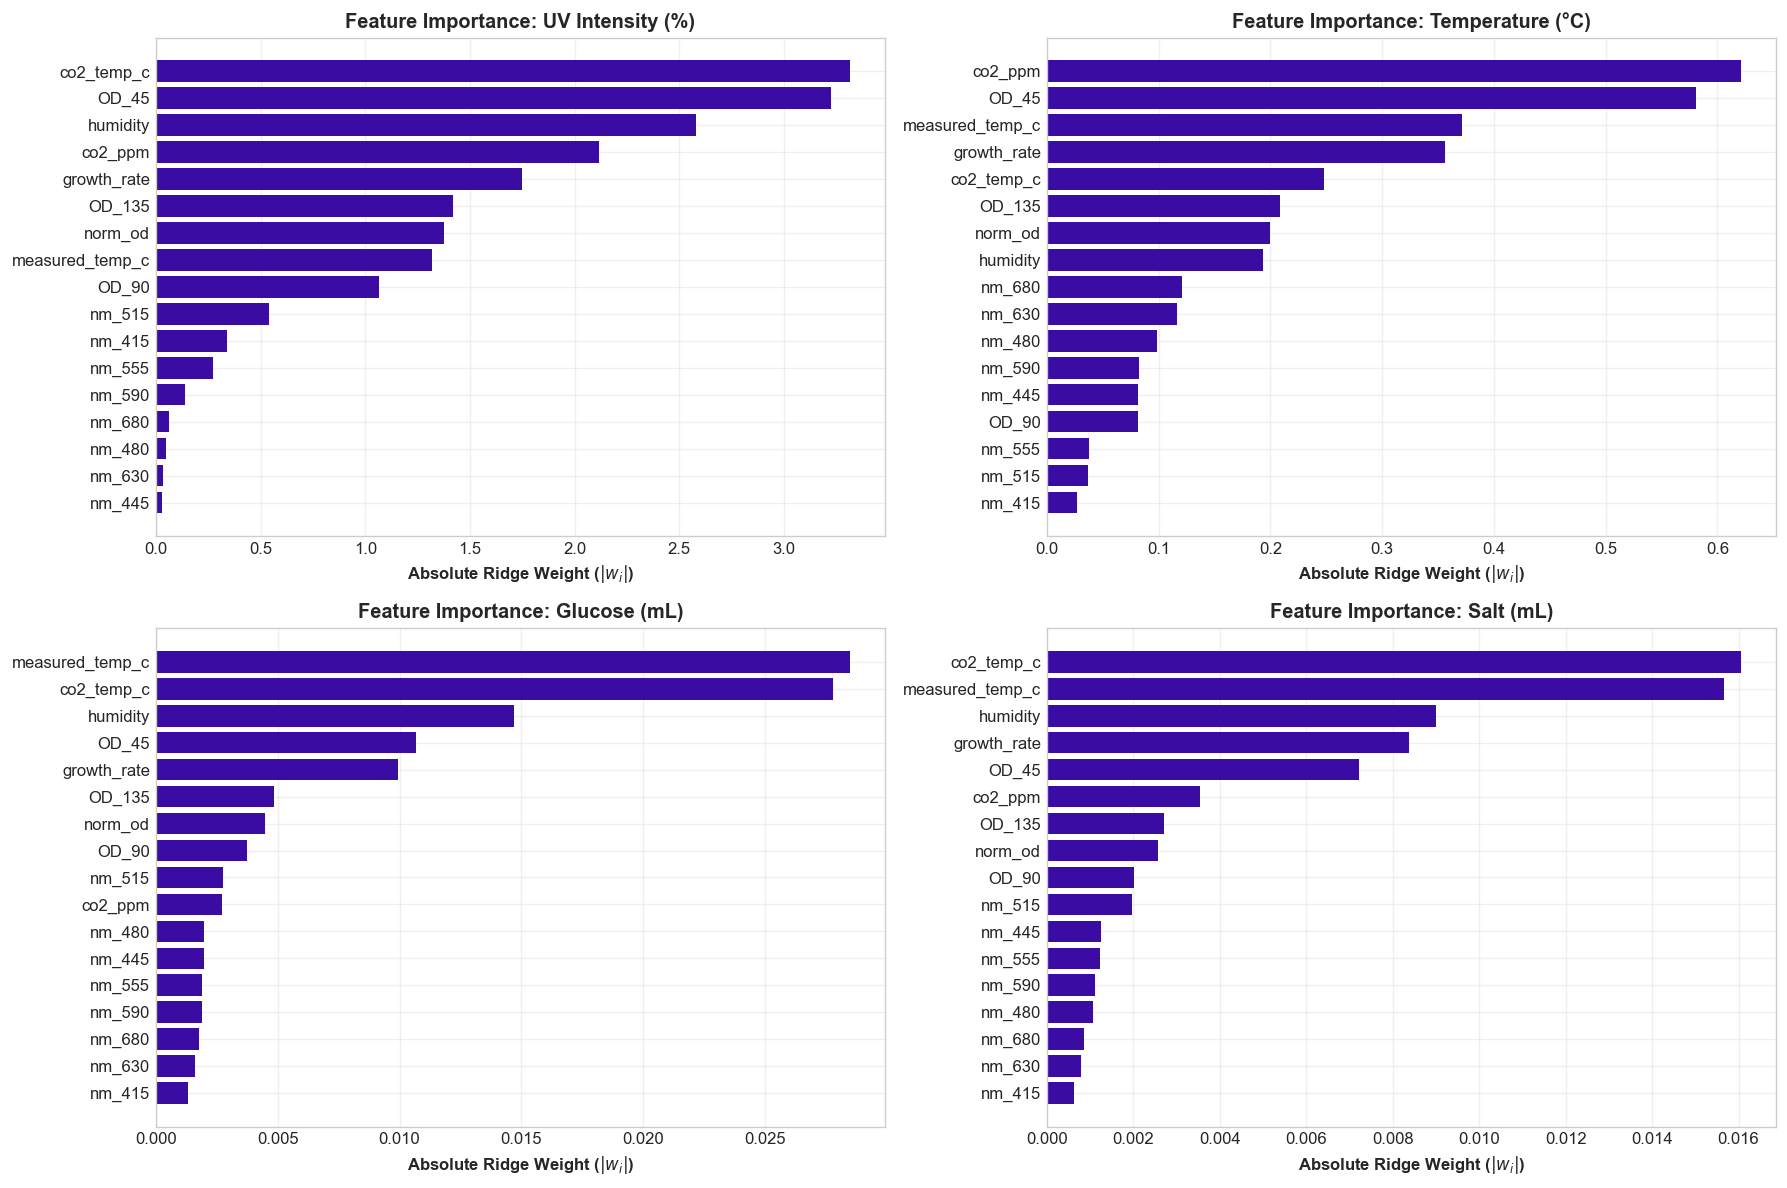

In [7]:
sc_fi = StandardScaler()
X_sc_fi = sc_fi.fit_transform(X_raw)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, y_t) in enumerate(targets):
    r_fi = Ridge(alpha=1.0)
    r_fi.fit(X_sc_fi, y_t)
    importance = np.abs(r_fi.coef_)
    sorted_idx = np.argsort(importance)
    
    axes[idx].barh(np.array(sensor_names)[sorted_idx], importance[sorted_idx], color='#3a0ca3')
    axes[idx].set_title(f'Feature Importance: {name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Absolute Ridge Weight ($|w_i|$)', fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
fi_plot_path = os.path.join(OUT_DIR, "feature_importance.png")
plt.savefig(fi_plot_path, dpi=150)
print(f"Saved feature importance ranking to: {fi_plot_path}")
plt.show()

### Section 7: Multidimensional Attractor Regime Classification

In [8]:
# Task 1: Binary UV (High >= 7% vs Low < 7%)
y_uv_bin = (u_uv >= 7.0).astype(int)

# Task 2: Binary Temp (Warm >= 27.5°C vs Cool < 27.5°C)
y_temp_bin = (u_temp >= 27.5).astype(int)

# Task 3: 4-Quadrant Attractor Regime (UV x Temp)
y_quad = (y_uv_bin * 2) + y_temp_bin

def run_classifier_benchmark(X, y, d=1):
    Xd, yd = delay_embed(X, y, d)
    scaler = StandardScaler()
    Xs = scaler.fit_transform(Xd)
    rcv = RidgeClassifierCV(alphas=np.logspace(-3, 3, 20))
    yp = cross_val_predict(rcv, Xs, yd, cv=LeaveOneOut())
    acc = accuracy_score(yd, yp)
    bal_acc = balanced_accuracy_score(yd, yp)
    f1 = f1_score(yd, yp, average='macro')
    cm = confusion_matrix(yd, yp)
    return yp, acc, bal_acc, f1, cm

print("=== CLASSIFICATION BENCHMARK RESULTS ===")
for task_name, y_t in [("Binary UV (High vs Low)", y_uv_bin),
                       ("Binary Temp (Warm vs Cool)", y_temp_bin),
                       ("4-Quadrant Attractor (UV x Temp)", y_quad)]:
    print(f"\n--- {task_name} ---")
    for d in [0, 1, 2]:
        yp_c, acc, bal_acc, f1, cm = run_classifier_benchmark(X_raw, y_t, d)
        print(f"Delay d={d} ({d*30:2d} min) -> Accuracy: {acc*100:.1f}%, Balanced Acc: {bal_acc*100:.1f}%, Macro F1: {f1:.4f}")

=== CLASSIFICATION BENCHMARK RESULTS ===

--- Binary UV (High vs Low) ---
Delay d=0 ( 0 min) -> Accuracy: 62.5%, Balanced Acc: 50.0%, Macro F1: 0.3846
Delay d=1 (30 min) -> Accuracy: 64.5%, Balanced Acc: 50.0%, Macro F1: 0.3922


Delay d=2 (60 min) -> Accuracy: 66.7%, Balanced Acc: 50.0%, Macro F1: 0.4000

--- Binary Temp (Warm vs Cool) ---
Delay d=0 ( 0 min) -> Accuracy: 53.1%, Balanced Acc: 50.0%, Macro F1: 0.3469


Delay d=1 (30 min) -> Accuracy: 41.9%, Balanced Acc: 38.2%, Macro F1: 0.2955
Delay d=2 (60 min) -> Accuracy: 36.7%, Balanced Acc: 32.4%, Macro F1: 0.2683

--- 4-Quadrant Attractor (UV x Temp) ---


Delay d=0 ( 0 min) -> Accuracy: 46.9%, Balanced Acc: 25.0%, Macro F1: 0.1596
Delay d=1 (30 min) -> Accuracy: 48.4%, Balanced Acc: 25.0%, Macro F1: 0.1630


Delay d=2 (60 min) -> Accuracy: 50.0%, Balanced Acc: 25.0%, Macro F1: 0.1667


### Section 8: Verification Controls & Genuineness Benchmarking

In [9]:
np.random.seed(42)

for name, y_t in targets:
    best_d = best_reconstructions[name][0]
    r2_true = best_reconstructions[name][5]
    Xd, yd = delay_embed(X_raw, y_t, best_d)
    
    # 1. Permutation / Target Shuffle Control (100 shuffles)
    r2_shuffs = []
    for _ in range(100):
        y_shuff = np.random.permutation(yd)
        _, _, _, r2_s, _ = ridge_loo_reg(Xd, y_shuff)
        r2_shuffs.append(r2_s)
    r2_shuff_mean = np.mean(r2_shuffs)
    p_val = np.mean(np.array(r2_shuffs) >= r2_true)
    
    # 2. Random Noise Feature Baseline
    X_noise = np.random.randn(*Xd.shape)
    _, _, _, r2_noise, _ = ridge_loo_reg(X_noise, yd)
    
    print(f"Target: {name:<22} (best delay d={best_d})")
    print(f"  • True Model R^2            : {r2_true:>7.4f}")
    print(f"  • Permuted Target Null R^2  : {r2_shuff_mean:>7.4f} (p-value = {p_val:.3f})")
    print(f"  • Random Noise Features R^2 : {r2_noise:>7.4f}")
    if r2_true > r2_shuff_mean:
        print(f"  ---> RESULT: Statistically Genuine encoding exceeding null controls.\n")
    else:
        print(f"  ---> RESULT: Below baseline due to low input variance.\n")

Target: UV Intensity (%)       (best delay d=0)
  • True Model R^2            :  0.0929
  • Permuted Target Null R^2  : -0.0412 (p-value = 0.030)
  • Random Noise Features R^2 : -0.0202
  ---> RESULT: Statistically Genuine encoding exceeding null controls.



Target: Temperature (°C)       (best delay d=3)
  • True Model R^2            :  0.2350
  • Permuted Target Null R^2  : -0.0388 (p-value = 0.000)
  • Random Noise Features R^2 : -0.0727
  ---> RESULT: Statistically Genuine encoding exceeding null controls.



Target: Glucose (mL)           (best delay d=0)
  • True Model R^2            : -0.0657
  • Permuted Target Null R^2  : -0.0450 (p-value = 1.000)
  • Random Noise Features R^2 : -0.0656
  ---> RESULT: Below baseline due to low input variance.



Target: Salt (mL)              (best delay d=1)
  • True Model R^2            : -0.0656
  • Permuted Target Null R^2  : -0.0272 (p-value = 0.380)
  • Random Noise Features R^2 : -0.0678
  ---> RESULT: Below baseline due to low input variance.



### Section 9: Reconstructed Multimodal Trajectories & Export

Saved multimodal reconstruction plots to: data/lorenz\results\multimodal_reconstructions.png


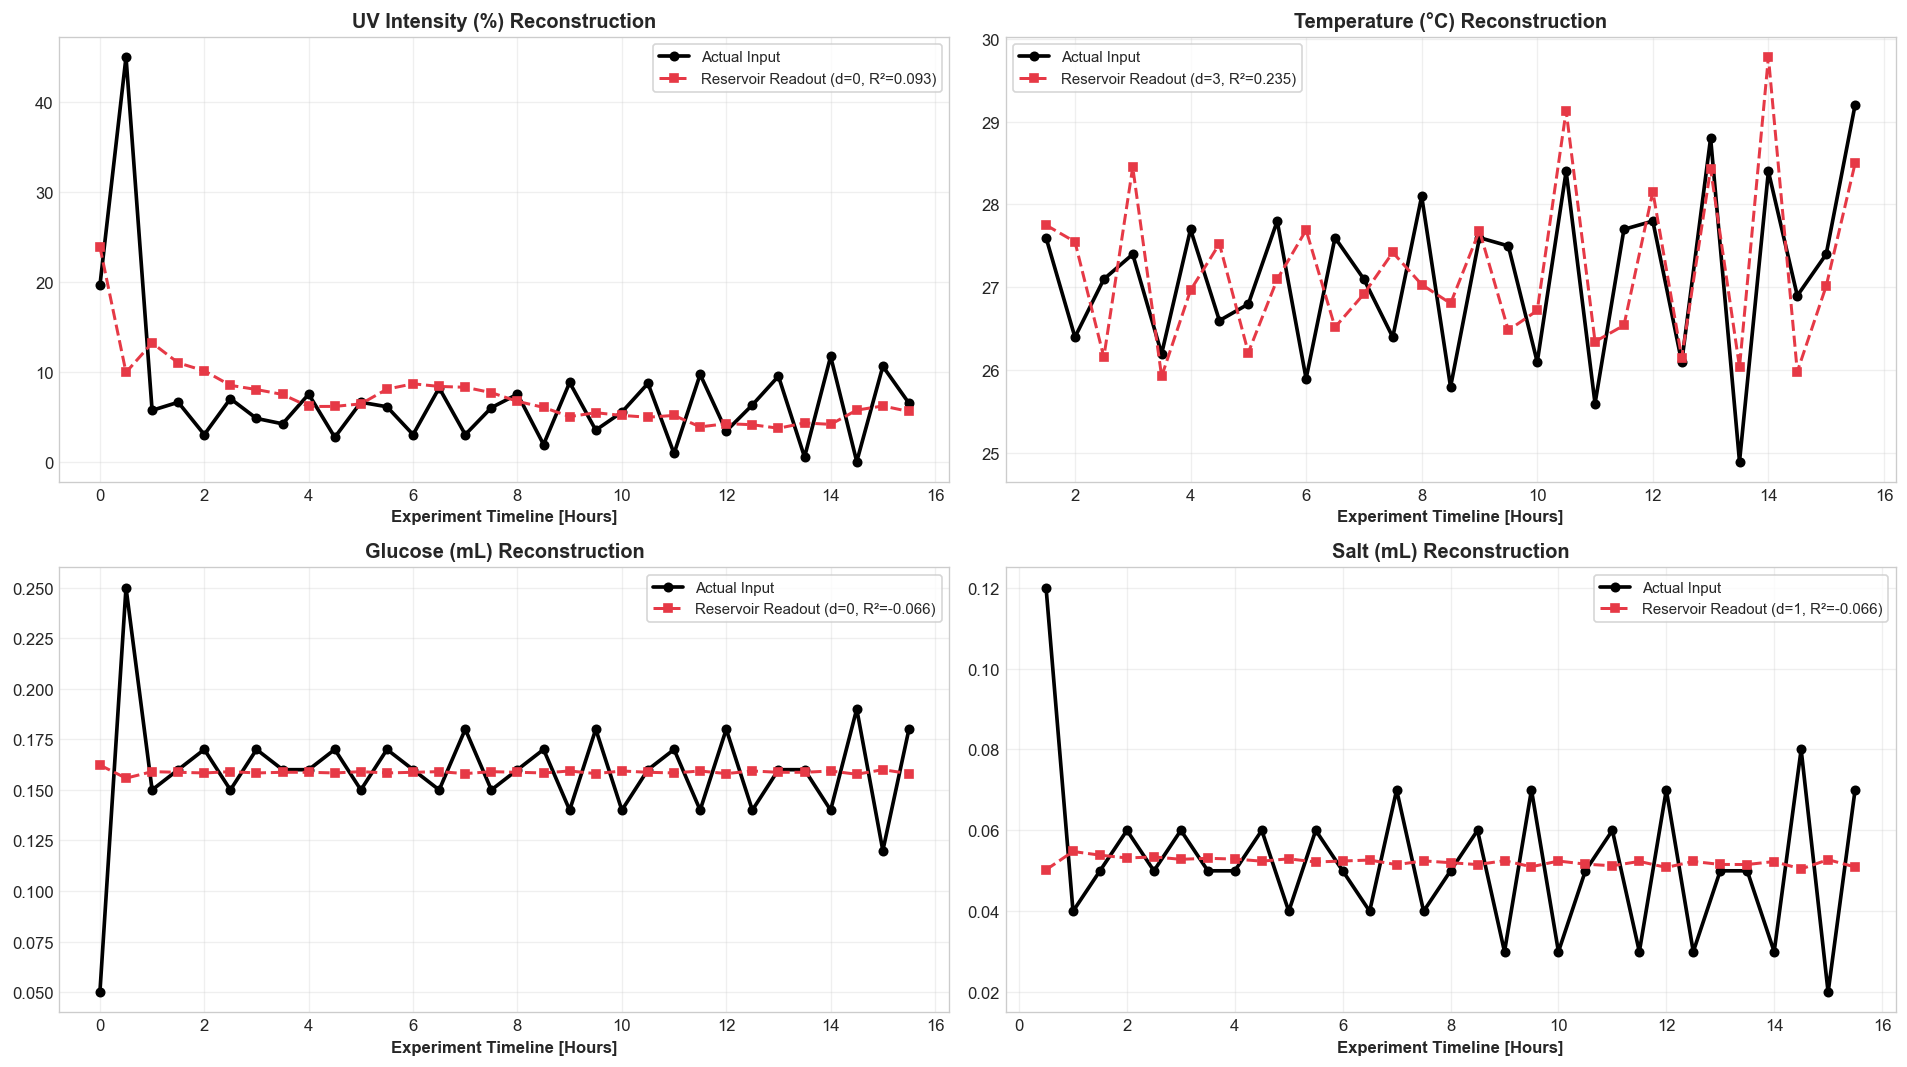

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

for idx, (name, y_t) in enumerate(targets):
    d, yp, yd, nmse, mae, r2 = best_reconstructions[name]
    time_hrs = np.arange(d, TOTAL_CYCLES) * (CYCLE_MIN / 60.0)
    
    axes[idx].plot(time_hrs, yd, label='Actual Input', color='#000000', lw=2.2, marker='o', ms=5)
    axes[idx].plot(time_hrs, yp, label=f'Reservoir Readout (d={d}, R²={r2:.3f})', color='#e63946', lw=1.8, ls='--', marker='s', ms=5)
    axes[idx].set_title(f'{name} Reconstruction', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Experiment Timeline [Hours]', fontweight='bold')
    axes[idx].legend(frameon=True, fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
recon_plot_path = os.path.join(OUT_DIR, "multimodal_reconstructions.png")
plt.savefig(recon_plot_path, dpi=150)
print(f"Saved multimodal reconstruction plots to: {recon_plot_path}")
plt.show()